In [ ]:
# ============================================================
# SETUP — Run this cell first
# ============================================================

# Uncomment and run once if packages are missing:
# !pip install wbgapi scikit-learn matplotlib seaborn numpy pandas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, lasso_path
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import wbgapi as wb

# Reproducibility
np.random.seed(42)

print("Setup complete ✓")


  Using cached altair-6.0.0-py3-none-any.whl.metadata (11 kB)
  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached cachetools-7.0.5-py3-none-any.whl.metadata (5.6 kB)
  Using cached click-8.3.1-py3-none-any.whl.metadata (2.6 kB)
  Using cached gitpython-3.1.46-py3-none-any.whl.metadata (13 kB)
  Using cached pydeck-0.9.1-py2.py3-none-any.whl.metadata (4.1 kB)
  Using cached pyarrow-23.0.1-cp314-cp314-macosx_12_0_arm64.whl.metadata (3.1 kB)
  Using cached tenacity-9.1.4-py3-none-any.whl.metadata (1.2 kB)
  Using cached toml-0.10.2-py2.py3-none-any.whl.metadata (7.1 kB)
  Using cached narwhals-2.18.1-py3-none-any.whl.metadata (14 kB)
  Using cached gitdb-4.0.12-py3-none-any.whl.metadata (1.2 kB)
  Using cached smmap-5.0.3-py3-none-any.whl.metadata (4.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 3.1 MB/s  0:00:03m0:00:0100:01
Using cached altair-6.0.0-py3-none-any.whl (795 kB)
Using cached blinker-1.9.0-py3-none-any.whl (8.5 kB)
Using cached cache

In [2]:
# ============================================================
# PART 1A: Download World Bank Data
# ============================================================

# WDI indicator codes for our predictors
# Format: 'indicator_code': 'human_readable_name'
INDICATORS = {
    # Growth outcome (our y)
    'NY.GDP.PCAP.KD.ZG': 'gdp_growth_pc',

    # Trade & Openness
    'NE.TRD.GNFS.ZS':    'trade_pct_gdp',
    'BX.KLT.DINV.WD.GD.ZS': 'fdi_inflows_pct_gdp',
    'TM.TAX.MRCH.SM.AR.ZS': 'tariff_rate_avg',
    'BX.GSR.ROYL.CD':    'royalties_receipts',

    # Macroeconomics
    'FP.CPI.TOTL.ZG':    'inflation_cpi',
    'GC.DOD.TOTL.GD.ZS': 'govt_debt_pct_gdp',
    'GC.XPN.TOTL.GD.ZS': 'govt_expenditure_pct_gdp',
    'BN.CAB.XOKA.GD.ZS': 'current_account_pct_gdp',
    'FR.INR.RINR':       'real_interest_rate',
    'PA.NUS.FCRF':       'exchange_rate_official',

    # Education & Human Capital
    'SE.SEC.ENRR':       'secondary_enrollment_gross',
    'SE.TER.ENRR':       'tertiary_enrollment_gross',
    'SE.ADT.LITR.ZS':    'adult_literacy_rate',
    'SE.XPD.TOTL.GD.ZS': 'education_expenditure_pct_gdp',
    'SL.UEM.TOTL.ZS':    'unemployment_rate',

    # Infrastructure & Technology
    'IT.NET.USER.ZS':    'internet_users_pct',
    'IT.CEL.SETS.P2':    'mobile_subscriptions_per100',
    'EG.ELC.ACCS.ZS':    'electricity_access_pct',
    'IS.ROD.PAVE.ZS':    'paved_roads_pct',

    # Health & Demographics
    'SP.DYN.LE00.IN':    'life_expectancy',
    'SH.DYN.MORT':       'infant_mortality_per1000',
    'SP.POP.GROW':       'population_growth',
    'SP.URB.TOTL.IN.ZS': 'urbanization_pct',
    'SH.XPD.CHEX.GD.ZS': 'health_expenditure_pct_gdp',

    # Finance & Banking
    'FS.AST.DOMS.GD.ZS': 'domestic_credit_pct_gdp',
    'CM.MKT.LCAP.GD.ZS': 'market_cap_pct_gdp',
    'FB.ATM.TOTL.P5':    'atms_per100k',
    'FD.AST.PRVT.GD.ZS': 'private_credit_pct_gdp',

    # Natural Resources
    'NY.GDP.TOTL.RT.ZS': 'natural_resource_rents_pct_gdp',
    'EG.FEC.RNEW.ZS':    'renewable_energy_pct',
    'EN.ATM.CO2E.PC':    'co2_emissions_per_capita',

    # Agriculture
    'NV.AGR.TOTL.ZS':    'agriculture_pct_gdp',
    'AG.LND.ARBL.ZS':    'arable_land_pct',

    # Governance (World Bank Governance Indicators)
    'IQ.CPA.TRAD.XQ':    'trade_cpia',
    'IQ.CPA.FINS.XQ':    'financial_management_cpia',
    'IQ.CPA.PROP.XQ':    'property_rights_cpia',
}

OUTCOME_VAR = 'gdp_growth_pc'
indicator_list = list(INDICATORS.keys())

print(f"Downloading {len(indicator_list)} indicators for all countries, 2013–2019...")
print("(This may take 30–60 seconds — API call to World Bank)")

# Download 7 years of data (2013–2019, pre-COVID) and average
# wb.data.DataFrame returns a DataFrame indexed by (economy, time) or (economy)
try:
    raw_data = wb.data.DataFrame(
        indicator_list,
        time=range(2013, 2020),  # 2013–2019
        skipBlanks=True,
        labels=False
    )
    raw_data.columns = [INDICATORS[c] if c in INDICATORS else c for c in raw_data.columns]
    print(f"Raw data shape: {raw_data.shape}")
    print("Download successful ✓")
except Exception as e:
    print(f"API error: {e}")
    print("Loading fallback data from CSV...")
    # Fallback: load pre-downloaded CSV
    # raw_data = pd.read_csv('data/fallback_wdi_topic16.csv', index_col=[0, 1])

(This may take 30–60 seconds — API call to World Bank)
Raw data shape: (7255, 7)
Download successful ✓


In [4]:
# ============================================================
# PART 1B: Build the Analysis Dataset
# ============================================================
# Average all indicators across the 2013-2019 period per country
# This gives us one observation per country — a cross-sectional dataset

# Average over time dimension
if isinstance(raw_data.index, pd.MultiIndex):
    time_avg = raw_data.mean(axis=1)
    country_data = time_avg.unstack(level=1)
    country_data.columns = [INDICATORS.get(c, c) for c in country_data.columns]
else:
    country_data = raw_data.copy()

# Drop countries with too many missing values (keep countries with >= 60% non-missing)
threshold = 0.60
country_data = country_data.dropna(thresh=int(threshold * country_data.shape[1]))

# Drop indicators with too many missing values across countries
country_data = country_data.dropna(axis=1, thresh=int(threshold * len(country_data)))

# Final fill: impute remaining missing values with the cross-country median
# (Standard practice in cross-country empirics — removes selection bias from listwise deletion)
country_data = country_data.fillna(country_data.median())

print(f"Final dataset: {len(country_data)} countries × {country_data.shape[1]} indicators")
print(f"\nSample countries: {list(country_data.index[:5])}")
print(f"\nIndicators retained: {list(country_data.columns)}")
print(f"\nGDP growth summary:")
print(country_data[OUTCOME_VAR].describe().round(2))

Final dataset: 238 countries × 29 indicators

Sample countries: ['ABW', 'AFE', 'AFG', 'AFW', 'AGO']

Indicators retained: ['arable_land_pct', 'current_account_pct_gdp', 'royalties_receipts', 'fdi_inflows_pct_gdp', 'electricity_access_pct', 'renewable_energy_pct', 'atms_per100k', 'private_credit_pct_gdp', 'inflation_cpi', 'real_interest_rate', 'govt_expenditure_pct_gdp', 'mobile_subscriptions_per100', 'internet_users_pct', 'trade_pct_gdp', 'agriculture_pct_gdp', 'gdp_growth_pc', 'natural_resource_rents_pct_gdp', 'exchange_rate_official', 'adult_literacy_rate', 'secondary_enrollment_gross', 'tertiary_enrollment_gross', 'education_expenditure_pct_gdp', 'infant_mortality_per1000', 'health_expenditure_pct_gdp', 'unemployment_rate', 'life_expectancy', 'population_growth', 'urbanization_pct', 'tariff_rate_avg']

GDP growth summary:
count    238.00
mean       1.76
std        2.45
min      -12.55
25%        0.57
50%        1.80
75%        3.30
max        7.39
Name: gdp_growth_pc, dtype: float64

In [5]:
# ============================================================
# PART 1C: Train-Test Split & OLS Baseline
# ============================================================
# We split countries (not time periods) into train/test sets.
# This tests whether our model generalizes across countries —
# the realistic use case for an IMF forecaster.

# Separate outcome (y) from predictors (X)
feature_cols = [c for c in country_data.columns if c != OUTCOME_VAR]

X = country_data[feature_cols].values
y = country_data[OUTCOME_VAR].values
feature_names = feature_cols

# 70/30 train-test split (stratified not needed for regression)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print(f"Training countries: {X_train.shape[0]}")
print(f"Test countries: {X_test.shape[0]}")
print(f"Number of predictors: {X_train.shape[1]}")
print(f"Predictor-to-observation ratio (train): p/n = {X_train.shape[1]}/{X_train.shape[0]} = {X_train.shape[1]/X_train.shape[0]:.2f}")
print()
print("If p/n > 0.5, OLS is at serious risk of overfitting.")

# Standardize features (critical for Ridge and Lasso — do it manually here to inspect later)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit on train only!
X_test_scaled  = scaler.transform(X_test)         # apply same transform to test

print("\nFeatures standardized (zero mean, unit variance) ✓")

Training countries: 166
Test countries: 72
Number of predictors: 28
Predictor-to-observation ratio (train): p/n = 28/166 = 0.17

If p/n > 0.5, OLS is at serious risk of overfitting.

Features standardized (zero mean, unit variance) ✓


In [7]:
# ============================================================
# PART 1D: OLS Baseline — Demonstrating the Failure Mode
# ============================================================
# OLS will overfit when p/n is large. We predict this BEFORE looking at results.
# Prediction: high training R², but much lower (possibly negative) test R².

ols_model = LinearRegression()
ols_model.fit(X_train_scaled, y_train)

# Training performance
y_train_pred_ols = ols_model.predict(X_train_scaled)
ols_train_r2  = r2_score(y_train, y_train_pred_ols)
ols_train_mse = mean_squared_error(y_train, y_train_pred_ols)

# Test performance
y_test_pred_ols = ols_model.predict(X_test_scaled)
ols_test_r2  = r2_score(y_test, y_test_pred_ols)
ols_test_mse = mean_squared_error(y_test, y_test_pred_ols)

print("=" * 45)
print("OLS BASELINE RESULTS")
print("=" * 45)
print(f"Training R²:  {ols_train_r2:.3f}")
print(f"Test R²:      {ols_test_r2:.3f}")
print(f"")
print(f"Training MSE: {ols_train_mse:.3f}")
print(f"Test MSE:     {ols_test_mse:.3f}")
print(f"")
print(f"Gap (Train R² - Test R²): {ols_train_r2 - ols_test_r2:.3f}")
print("=" * 45)
print()
print("Interpretation:")
print(f"  OLS fits the training data {ols_train_r2:.0%} — but only explains")
print(f"  {max(ols_test_r2, 0):.0%} of test variance. This is overfitting.")

OLS BASELINE RESULTS
Training R²:  0.600
Test R²:      -0.849

Training MSE: 2.640
Test MSE:     8.252

Gap (Train R² - Test R²): 1.449

Interpretation:
  OLS fits the training data 60% — but only explains
  0% of test variance. This is overfitting.


In [9]:
# ============================================================
# PART 2A: Ridge Regression with Cross-Validated Lambda
# ============================================================
# YOUR TASK: Complete the RidgeCV fit below.
# RidgeCV tries all alphas in the list and picks the one with
# lowest cross-validation error.
#
# Note: sklearn calls λ "alpha" for historical reasons.

# Grid of lambda (alpha) values to try — log-spaced from 0.01 to 1000
lambda_grid = np.logspace(-2, 3, 50)

# TODO: Create a RidgeCV with 5-fold CV and the lambda_grid above
# Hint: RidgeCV(alphas=..., cv=5)
ridge_cv = RidgeCV(alphas=lambda_grid, cv=5)  # ← complete this line

# TODO: Fit ridge_cv on the scaled training data
ridge_cv.fit(X_train_scaled, y_train)  # ← complete this line

# Evaluate on test set
y_test_pred_ridge = ridge_cv.predict(X_test_scaled)
ridge_test_r2  = r2_score(y_test, y_test_pred_ridge)
ridge_test_mse = mean_squared_error(y_test, y_test_pred_ridge)

print("=" * 45)
print("RIDGE REGRESSION RESULTS")
print("=" * 45)
print(f"Optimal λ* (CV-selected): {ridge_cv.alpha_:.4f}")
print(f"Non-zero coefficients:    {np.sum(ridge_cv.coef_ != 0)} of {X_train.shape[1]}")
print(f"Test R²:                  {ridge_test_r2:.3f}")
print(f"Test MSE:                 {ridge_test_mse:.3f}")
print()
print(f"vs. OLS: Test R² = {ols_test_r2:.3f}, Test MSE = {ols_test_mse:.3f}")

RIDGE REGRESSION RESULTS
Optimal λ* (CV-selected): 47.1487
Non-zero coefficients:    28 of 28
Test R²:                  -0.051
Test MSE:                 4.691

vs. OLS: Test R² = -0.849, Test MSE = 8.252


In [11]:
# ============================================================
# PART 2B: LassoCV — Automated Feature Selection
# ============================================================

def fit_lasso_cv(X_train, y_train, X_test, y_test, cv=5):
    """
    Fit LassoCV to select optimal regularization parameter and evaluate on test set.

    Parameters
    ----------
    X_train : np.ndarray, shape (n_train, p)
        Standardized training features
    y_train : np.ndarray, shape (n_train,)
        Training outcome (GDP growth)
    X_test : np.ndarray, shape (n_test, p)
        Standardized test features (same scaler as train)
    y_test : np.ndarray, shape (n_test,)
        Test outcome
    cv : int
        Number of cross-validation folds

    Returns
    -------
    lasso_model : LassoCV
        Fitted LassoCV model with optimal alpha stored in .alpha_
    test_r2 : float
        R² on held-out test set
    test_mse : float
        Mean squared error on held-out test set
    """
    # TODO: Create a LassoCV with cv folds and max_iter=10_000
    # (max_iter needs to be high for coordinate descent to converge)
    lasso_model = LassoCV(cv=cv, max_iter=10_000, random_state=42)  # ← your code here

    # TODO: Fit the model on training data
    lasso_model.fit(X_train, y_train)  # ← your code here

    # Predict on test set
    y_pred = lasso_model.predict(X_test)

    # TODO: Compute test R² and test MSE
    test_r2  = r2_score(y_test, y_pred)  # ← your code here
    test_mse = mean_squared_error(y_test, y_pred)  # ← your code here

    return lasso_model, test_r2, test_mse


# Call the function
lasso_cv_model, lasso_test_r2, lasso_test_mse = fit_lasso_cv(
    X_train_scaled, y_train, X_test_scaled, y_test, cv=5
)

n_nonzero = np.sum(lasso_cv_model.coef_ != 0)

print("=" * 45)
print("LASSO REGRESSION RESULTS")
print("=" * 45)
print(f"Optimal λ* (CV-selected): {lasso_cv_model.alpha_:.4f}")
print(f"Non-zero coefficients:    {n_nonzero} of {X_train.shape[1]}")
print(f"Test R²:                  {lasso_test_r2:.3f}")
print(f"Test MSE:                 {lasso_test_mse:.3f}")
print()
print("Selected predictors (non-zero Lasso coefficients):")
selected_features = [
    (feature_names[i], lasso_cv_model.coef_[i])
    for i in range(len(feature_names))
    if lasso_cv_model.coef_[i] != 0
]
for name, coef in sorted(selected_features, key=lambda x: abs(x[1]), reverse=True):
    print(f"  {name:<40} coef = {coef:+.4f}")

LASSO REGRESSION RESULTS
Optimal λ* (CV-selected): 0.0656
Non-zero coefficients:    17 of 28
Test R²:                  -0.330
Test MSE:                 5.934

Selected predictors (non-zero Lasso coefficients):
  inflation_cpi                            coef = -1.0240
  population_growth                        coef = -0.7706
  natural_resource_rents_pct_gdp           coef = -0.6521
  health_expenditure_pct_gdp               coef = -0.4145
  infant_mortality_per1000                 coef = -0.3856
  atms_per100k                             coef = -0.3850
  unemployment_rate                        coef = -0.3716
  renewable_energy_pct                     coef = +0.3627
  urbanization_pct                         coef = -0.3546
  exchange_rate_official                   coef = +0.3112
  arable_land_pct                          coef = +0.1881
  tertiary_enrollment_gross                coef = -0.0797
  mobile_subscriptions_per100              coef = +0.0729
  private_credit_pct_gdp            

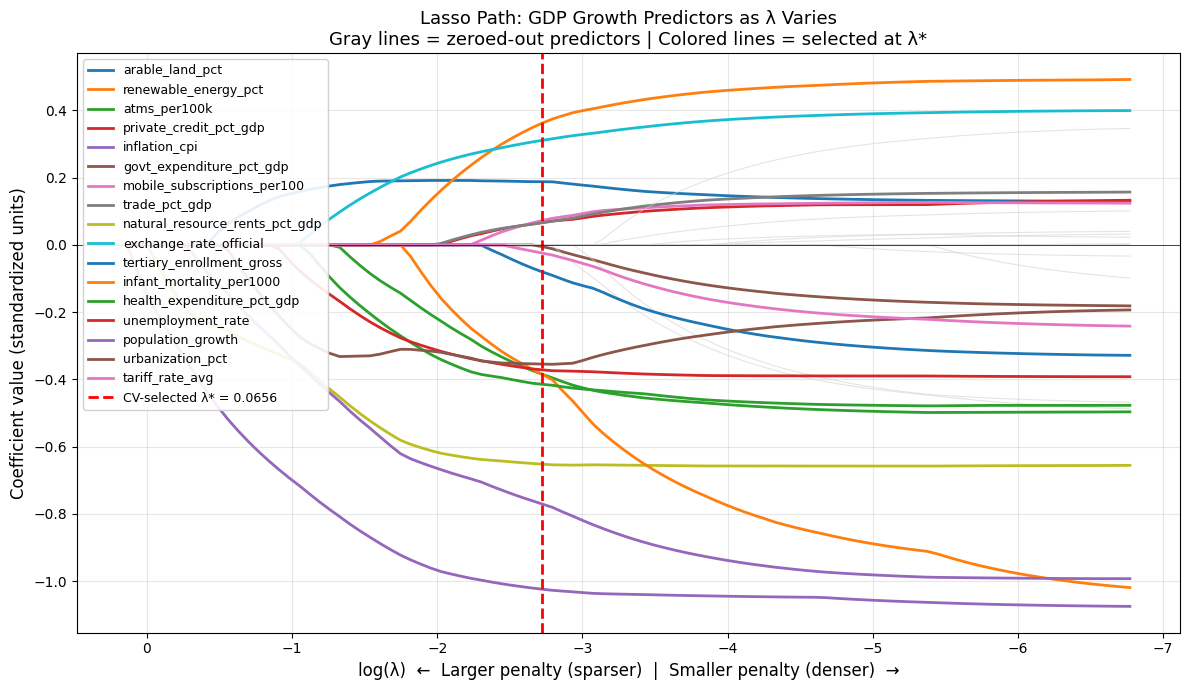

Lasso Path saved to lasso_path_gdp_growth.png


In [12]:
# ============================================================
# PART 2C: The Lasso Path — Who Enters First?
# ============================================================
# The Lasso Path traces ALL coefficient estimates as λ varies.
# - Far right (large λ): all coefficients are zero
# - Moving left (smaller λ): variables enter one by one
# - The FIRST variable to enter = the single strongest predictor
# - The vertical dashed line = our CV-selected λ*

# Compute the Lasso path using LARS algorithm (efficient — no loop needed)
# lasso_path returns: (alphas, coefs, dual_gaps)
alphas_path, coefs_path, _ = lasso_path(
    X_train_scaled, y_train,
    eps=1e-3,       # ratio of min to max alpha in the path
    n_alphas=100,   # number of points on the path
)
# coefs_path shape: (n_features, n_alphas)

# Mark our CV-selected lambda
optimal_alpha = lasso_cv_model.alpha_

# ── PLOT ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

# Plot each predictor's coefficient path
# Only label the lines that are non-zero at optimal λ (to avoid clutter)
active_features_idx = np.where(lasso_cv_model.coef_ != 0)[0]

for i in range(len(feature_names)):
    if i in active_features_idx:
        ax.plot(np.log(alphas_path), coefs_path[i],
                linewidth=2, label=feature_names[i])
    else:
        ax.plot(np.log(alphas_path), coefs_path[i],
                linewidth=0.8, color='lightgray', alpha=0.6)

# Mark the CV-selected lambda
ax.axvline(np.log(optimal_alpha), color='red', linestyle='--', linewidth=2,
           label=f'CV-selected λ* = {optimal_alpha:.4f}')
ax.axhline(0, color='black', linewidth=0.5)

# Labels and formatting
ax.set_xlabel('log(λ)  ←  Larger penalty (sparser)  |  Smaller penalty (denser)  →',
               fontsize=12)
ax.set_ylabel('Coefficient value (standardized units)', fontsize=12)
ax.set_title(
    'Lasso Path: GDP Growth Predictors as λ Varies\n'
    'Gray lines = zeroed-out predictors | Colored lines = selected at λ*',
    fontsize=13
)
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax.invert_xaxis()  # Large lambda on left → small lambda on right (path goes left to right)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lasso_path_gdp_growth.png', dpi=150, bbox_inches='tight')
plt.show()
print("Lasso Path saved to lasso_path_gdp_growth.png")

In [13]:
# ============================================================
# PART 2D: Model Comparison Table
# ============================================================
# Complete the table below — fill in the Lasso and OLS values
# using variables computed above.

comparison = pd.DataFrame({
    'Method': ['OLS', 'Ridge (RidgeCV)', 'Lasso (LassoCV)'],
    'Lambda (α*)': [
        'N/A (no penalty)',
        f'{ridge_cv.alpha_:.4f}',
        f'{lasso_cv_model.alpha_:.4f}'
    ],
    'Non-zero Predictors': [
        X_train.shape[1],                        # OLS: all predictors non-zero
        X_train.shape[1],                        # Ridge: all predictors non-zero
        np.sum(lasso_cv_model.coef_ != 0)        # Lasso: only selected predictors
    ],
    'Training R²': [
        f'{r2_score(y_train, ols_model.predict(X_train_scaled)):.3f}',
        f'{r2_score(y_train, ridge_cv.predict(X_train_scaled)):.3f}',
        f'{r2_score(y_train, lasso_cv_model.predict(X_train_scaled)):.3f}'
    ],
    'Test R²': [
        f'{ols_test_r2:.3f}',
        f'{ridge_test_r2:.3f}',
        f'{lasso_test_r2:.3f}'
    ],
    'Test MSE': [
        f'{ols_test_mse:.3f}',
        f'{ridge_test_mse:.3f}',
        f'{lasso_test_mse:.3f}'
    ]
})

print(comparison.to_string(index=False))
print()
print("Key observations:")
print(f"  • OLS training R² >> test R²: evidence of overfitting (high variance)")
print(f"  • Ridge and Lasso reduce the train-test gap")
print(f"  • Lasso selects only {np.sum(lasso_cv_model.coef_ != 0)} of {X_train.shape[1]} predictors")
print(f"  • Interpretation: the other {X_train.shape[1] - np.sum(lasso_cv_model.coef_ != 0)} are predictively redundant,")
print(f"    not necessarily economically unimportant")

         Method      Lambda (α*)  Non-zero Predictors Training R² Test R² Test MSE
            OLS N/A (no penalty)                   28       0.600  -0.849    8.252
Ridge (RidgeCV)          47.1487                   28       0.557  -0.051    4.691
Lasso (LassoCV)           0.0656                   17       0.569  -0.330    5.934

Key observations:
  • OLS training R² >> test R²: evidence of overfitting (high variance)
  • Ridge and Lasso reduce the train-test gap
  • Lasso selects only 17 of 28 predictors
  • Interpretation: the other 11 are predictively redundant,
    not necessarily economically unimportant


Question 1: Lasso zeroing out paved_roads_pct means it added nothing to predictions given the other variables already in the model. This is conditional predictive redundancy, not irrelevance. Roads are heavily correlated with electricity access, internet usage, and other development indicators, so Lasso can get the same predictive signal from those instead. That says nothing about whether roads have a causal relationship with growth; it just means the information was already captured elsewhere in the correlation structure of this particular dataset. 

Question 2: For this dataset, Ridge is probably the better default. When predictors are highly correlated, like internet access and electricity both proxying for development level, Lasso tends to arbitrarily pick one and zero the others, which is unstable and hard to interpret. Ridge shrinks all correlated predictors together, which is more appropriate when you don't actually believe most variables are irrelevant. The high p/n ratio does call for regularization, but given that our indicators are overlapping proxies rather than a mix of signal and pure noise, Ridge's "shrink everything" approach fits the data structure better than Lasso's forced sparsity.

In [21]:
import pickle
with open("dashboard_data.pkl", "wb") as f:
    pickle.dump({
        "feature_names": feature_names,
        "X_train_scaled": X_train_scaled,
        "X_test_scaled": X_test_scaled,
        "y_train": y_train,
        "y_test": y_test,
    }, f)
print("Saved ✓")

# ============================================================
# regularization_dashboard.py
# World Bank WDI — Regularization Explorer
# Run with: streamlit run regularization_dashboard.py
# ============================================================
#
# HOW TO INTEGRATE WITH YOUR NOTEBOOK:
# This app expects your processed variables to be saved first.
# At the bottom of your notebook, add one cell:
#
#   import pickle
#   with open("dashboard_data.pkl", "wb") as f:
#       pickle.dump({
#           "country_data": country_data,
#           "OUTCOME_VAR": OUTCOME_VAR,
#           "feature_names": feature_names,
#           "X_train_scaled": X_train_scaled,
#           "X_test_scaled": X_test_scaled,
#           "y_train": y_train,
#           "y_test": y_test,
#       }, f)
#
# Then run: streamlit run regularization_dashboard.py
# ============================================================

import streamlit as st
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pickle
import os

from sklearn.linear_model import Ridge, Lasso, lasso_path
from sklearn.metrics import r2_score

# ── Page config ─────────────────────────────────────────────
st.set_page_config(
    page_title="Regularization Explorer",
    layout="wide",
    initial_sidebar_state="expanded",
)

# ── Minimal dark-ish style injected via markdown ─────────────
st.markdown("""
<style>
    .block-container { padding-top: 1.5rem; }
    h1 { font-size: 1.6rem; font-weight: 700; letter-spacing: -0.5px; }
    h3 { font-size: 1.05rem; font-weight: 600; color: #555; }
    .stSlider > div { padding-top: 0.3rem; }
    .metric-box {
        background: #f7f8fa;
        border-radius: 8px;
        padding: 0.75rem 1rem;
        text-align: center;
        border: 1px solid #e2e5ea;
    }
    .metric-box .val { font-size: 1.6rem; font-weight: 700; }
    .metric-box .lbl { font-size: 0.75rem; color: #888; text-transform: uppercase; }
</style>
""", unsafe_allow_html=True)


# ── Load data ────────────────────────────────────────────────
@st.cache_data
def load_data(path="dashboard_data.pkl"):
    """
    Load the pre-processed arrays saved from your notebook.
    @st.cache_data means this only runs once per session —
    subsequent re-runs caused by slider moves skip this entirely.
    """
    if not os.path.exists(path):
        st.error(
            f"**{path} not found.**\n\n"
            "Run the export cell in your notebook first (see comments at top of this file)."
        )
        st.stop()
    with open(path, "rb") as f:
        d = pickle.load(f)
    return (
        d["feature_names"],
        d["X_train_scaled"],
        d["X_test_scaled"],
        d["y_train"],
        d["y_test"],
    )

feature_names, X_train_scaled, X_test_scaled, y_train, y_test = load_data()


# ── Pre-compute the full Lasso Path (expensive — cache it) ───
@st.cache_data
def compute_lasso_path(X_train, y_train):
    """
    sklearn's lasso_path() computes the entire coefficient trajectory
    across a grid of alpha (lambda) values in one efficient pass using
    coordinate descent warm-starting.

    We cache this with @st.cache_data so it runs ONCE when the app first
    loads and is never recomputed when the user moves the slider.
    The slider only changes which vertical line we draw on the plot —
    it does NOT re-run this function.

    Returns
    -------
    alphas : array of shape (n_alphas,)
        Descending sequence of lambda values (large → small).
    coefs  : array of shape (n_features, n_alphas)
        Coefficient matrix. coefs[:, k] gives all feature coefficients
        at regularization strength alphas[k].
    """
    alphas, coefs, _ = lasso_path(X_train, y_train, eps=1e-4, n_alphas=100)
    return alphas, coefs

alphas_path, coefs_path = compute_lasso_path(X_train_scaled, y_train)


# ── Fit a single model at a given lambda (fast, runs on every slider move) ──
def fit_model(model_type: str, lam: float):
    """
    Refit Ridge or Lasso at the lambda value currently selected by the slider.

    This IS recomputed on every slider interaction — but it's cheap
    (a single coordinate-descent or ridge solve, not a grid search).
    Streamlit's execution model re-runs the entire script top-to-bottom
    whenever any widget changes; this function is called inside that re-run.

    Returns coefficients, train R², test R².
    """
    if model_type == "Lasso":
        model = Lasso(alpha=lam, max_iter=10_000)
    else:
        model = Ridge(alpha=lam)

    model.fit(X_train_scaled, y_train)

    train_r2 = r2_score(y_train, model.predict(X_train_scaled))
    test_r2  = r2_score(y_test,  model.predict(X_test_scaled))

    return model.coef_, train_r2, test_r2


# ═══════════════════════════════════════════════════════════════
# SIDEBAR — Controls
# ═══════════════════════════════════════════════════════════════
with st.sidebar:
    st.title("⚙️ Controls")
    st.markdown("---")

    model_choice = st.radio(
        "Model",
        ["Lasso", "Ridge"],
        help="Lasso drives coefficients to exactly zero. Ridge shrinks all coefficients toward zero but keeps them non-zero.",
    )

    st.markdown("#### Regularization Strength (λ)")
    st.caption("Higher λ → more shrinkage → fewer non-zero coefficients")

    # Log-scale slider: exponent from -3 to 3, displayed as 10^exp
    # Using log scale makes it easy to explore a wide range precisely.
    log_lam = st.slider(
        "log₁₀(λ)",
        min_value=-3.0,
        max_value=3.0,
        value=0.0,          # default: λ = 1.0
        step=0.05,
        format="%.2f",
        # When the user moves this slider, Streamlit re-runs the script.
        # The new log_lam value is read here, converted to lam below,
        # and passed to fit_model() — which refits at the new lambda.
    )
    lam = 10 ** log_lam     # convert exponent back to actual lambda value

    st.markdown(f"**λ = {lam:.4f}**")
    st.markdown("---")

    # Reference lines for CV-optimal lambdas (computed once)
    @st.cache_data
    def get_cv_lambdas(X_train, y_train):
        from sklearn.linear_model import LassoCV, RidgeCV
        lasso_cv = LassoCV(cv=5, max_iter=10_000, random_state=42).fit(X_train, y_train)
        ridge_cv = RidgeCV(alphas=np.logspace(-2, 3, 50), cv=5).fit(X_train, y_train)
        return lasso_cv.alpha_, ridge_cv.alpha_

    lasso_cv_lam, ridge_cv_lam = get_cv_lambdas(X_train_scaled, y_train)
    cv_lam = lasso_cv_lam if model_choice == "Lasso" else ridge_cv_lam

    st.markdown(f"**CV-optimal λ:** `{cv_lam:.4f}`")
    if st.button("Jump to CV-optimal λ"):
        # Can't programmatically move the slider, but we show what to set it to
        st.info(f"Set log₁₀(λ) = **{np.log10(cv_lam):.2f}** on the slider above.")

    st.markdown("---")
    show_zero_only = st.checkbox(
        "Highlight non-zero coefficients only",
        value=False,
        help="In the coefficient chart, grey out features Lasso has zeroed out.",
    )


# ═══════════════════════════════════════════════════════════════
# FIT MODEL at current lambda
# ═══════════════════════════════════════════════════════════════
# This runs on every slider interaction.
coefs, train_r2, test_r2 = fit_model(model_choice, lam)
n_nonzero = int(np.sum(coefs != 0))


# ═══════════════════════════════════════════════════════════════
# HEADER
# ═══════════════════════════════════════════════════════════════
st.title("🌍 WDI Regularization Explorer")
st.caption(
    f"Cross-sectional GDP growth prediction · {X_train_scaled.shape[0]} training countries · "
    f"{len(feature_names)} predictors"
)

# Quick metric row
m1, m2, m3, m4 = st.columns(4)
for col, val, label, color in zip(
    [m1, m2, m3, m4],
    [f"{lam:.4f}", f"{train_r2:.3f}", f"{test_r2:.3f}", f"{n_nonzero}/{len(feature_names)}"],
    ["Current λ", "Train R²", "Test R²", "Non-zero coefs"],
    ["#1a1a2e", "#2d6a4f", "#1565c0", "#6a1b4d"],
):
    col.markdown(
        f'<div class="metric-box"><div class="val" style="color:{color}">{val}</div>'
        f'<div class="lbl">{label}</div></div>',
        unsafe_allow_html=True,
    )

st.markdown("<br>", unsafe_allow_html=True)


# ═══════════════════════════════════════════════════════════════
# THREE PANELS
# ═══════════════════════════════════════════════════════════════
col_left, col_right = st.columns([1.1, 1], gap="large")

# ── Panel 1: Coefficient Bar Chart ──────────────────────────
with col_left:
    st.markdown("### Panel 1 — Coefficients at Current λ")
    st.caption(
        "Each bar is the coefficient magnitude for one WDI indicator. "
        "Lasso sets unimportant predictors to exactly zero. Ridge shrinks all."
    )

    fig1, ax1 = plt.subplots(figsize=(6.5, max(4, len(feature_names) * 0.25)))

    sorted_idx = np.argsort(np.abs(coefs))
    sorted_coefs = coefs[sorted_idx]
    sorted_names = [feature_names[i] for i in sorted_idx]

    # Color: blue for positive, red for negative, grey for zero
    bar_colors = []
    for c in sorted_coefs:
        if c == 0:
            bar_colors.append("#d0d0d0")
        elif c > 0:
            bar_colors.append("#1565c0")
        else:
            bar_colors.append("#c62828")

    bars = ax1.barh(sorted_names, sorted_coefs, color=bar_colors, edgecolor="none", height=0.7)
    ax1.axvline(0, color="#333", linewidth=0.8)
    ax1.set_xlabel("Standardized Coefficient", fontsize=9)
    ax1.tick_params(axis="y", labelsize=7.5)
    ax1.tick_params(axis="x", labelsize=8)
    ax1.spines[["top", "right"]].set_visible(False)
    ax1.set_title(
        f"{model_choice} · λ = {lam:.4f} · {n_nonzero} non-zero",
        fontsize=9, pad=8, color="#333"
    )
    fig1.tight_layout()
    st.pyplot(fig1, use_container_width=True)
    plt.close(fig1)


# ── Panel 2: Lasso Path ──────────────────────────────────────
with col_right:
    st.markdown("### Panel 2 — Lasso Path")
    st.caption(
        "Each line is one indicator's coefficient as λ decreases (left = max penalty, right = near-OLS). "
        "The **vertical line** marks your current λ."
    )

    fig2, ax2 = plt.subplots(figsize=(6, 4.5))

    # Plot coefficient trajectory for each feature
    # coefs_path shape: (n_features, n_alphas) — columns are sorted large→small alpha
    neg_log_alphas = -np.log10(alphas_path)   # x-axis: larger = less regularization

    for i, name in enumerate(feature_names):
        ax2.plot(neg_log_alphas, coefs_path[i], linewidth=0.9, alpha=0.75)

    # Vertical line at selected lambda — updated every time slider moves.
    # We convert the current lam to the same -log10 scale used on the x-axis.
    current_x = -np.log10(lam)
    ax2.axvline(
        current_x,
        color="#e53935",
        linewidth=1.8,
        linestyle="--",
        label=f"λ = {lam:.4f}",
        zorder=5,
    )

    ax2.set_xlabel("−log₁₀(λ)   [← more regularization | less regularization →]", fontsize=8)
    ax2.set_ylabel("Coefficient", fontsize=8)
    ax2.tick_params(labelsize=8)
    ax2.spines[["top", "right"]].set_visible(False)
    ax2.legend(fontsize=8, loc="upper left")
    ax2.set_title("Lasso Path (cached)", fontsize=9, pad=8, color="#333")
    fig2.tight_layout()
    st.pyplot(fig2, use_container_width=True)
    plt.close(fig2)


# ── Panel 3: Train / Test R² Comparison ──────────────────────
st.markdown("### Panel 3 — Train vs Test R² at Current λ")
st.caption(
    "The gap between the bars is your overfitting signal. "
    "A well-regularized model minimizes this gap while keeping test R² high."
)

fig3, ax3 = plt.subplots(figsize=(4.5, 2.8))

bars3 = ax3.bar(
    ["Train R²", "Test R²"],
    [train_r2, test_r2],
    color=["#1565c0", "#2d6a4f"],
    width=0.45,
    edgecolor="none",
)

# Annotate bar values
for bar, val in zip(bars3, [train_r2, test_r2]):
    ax3.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{val:.3f}",
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )

ax3.set_ylim(min(0, test_r2 - 0.1), 1.05)
ax3.axhline(0, color="#aaa", linewidth=0.7)
ax3.set_ylabel("R²", fontsize=9)
ax3.tick_params(labelsize=10)
ax3.spines[["top", "right", "left"]].set_visible(False)
ax3.set_title(f"Overfitting gap: {train_r2 - test_r2:.3f}", fontsize=9, color="#c62828")
fig3.tight_layout()

c1, c2, c3 = st.columns([1, 1.2, 1])
with c2:
    st.pyplot(fig3, use_container_width=True)
plt.close(fig3)


# ═══════════════════════════════════════════════════════════════
# INTERPRETATION GUIDE (collapsible)
# ═══════════════════════════════════════════════════════════════
with st.expander("📖 How to interpret this dashboard"):
    st.markdown("""
**High λ (slider far right — log₁₀λ → 3)**
All coefficients shrink toward zero. The model essentially predicts the mean GDP growth for
every country regardless of their indicators. Train R² and test R² both collapse toward zero
or negative values. You've added so much bias that the model can't fit signal or noise.

**Low λ (slider far left — log₁₀λ → −3)**
Regularization is nearly gone — you're approaching OLS. Train R² climbs toward 1.0 because
the model memorizes the training countries. Test R² drops or goes negative because those
memorized patterns don't generalize. The bar chart will show many large, non-zero
coefficients. This is the overfitting regime.

**CV-optimal λ**
This is where cross-validation found the best bias-variance tradeoff. Train R² is moderately
high, test R² is as high as it can get, and the gap between them is minimized. The Lasso
path vertical line sits where only the most predictive indicators have entered (non-zero
coefficients). This is your operating point.

**Lasso Path (Panel 2)**
Features that cross zero (enter the model) earliest as λ decreases from left to right are
the indicators Lasso considers most predictive, conditional on all others. Features that
stay flat at zero until very low λ are either genuinely weak predictors or redundant with
others already in the model — you can't tell which from the path alone.

**Train/Test gap**
The gap shrinks as λ increases (more regularization) and explodes as λ decreases toward OLS.
The CV-optimal λ is approximately where the gap is minimized *while test R² is still positive*.
    """)

Saved ✓


2026-04-01 17:09:07.592 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-01 17:09:07.593 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-01 17:09:07.622 
  command:

    streamlit run /Users/jordi/Desktop/econ3916/venv/lib/python3.14/site-packages/ipykernel_launcher.py [ARGUMENTS]
2026-04-01 17:09:07.622 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-01 17:09:07.622 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-01 17:09:07.622 No runtime found, using MemoryCacheStorageManager
2026-04-01 17:09:07.623 No runtime found, using MemoryCacheStorageManager
2026-04-01 17:09:07.623 Thread 'MainThread': missing ScriptRunCon